# Polarization Entanglement-Swapping Tomography

This notebook validates every combination of the two source Bell states. For each source pair, it conditions Alice-David tomography on the two Bell states that the four-detector linear-optical BSM can identify: $\Psi^-$ and $\Psi^+$.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from simulator import (
    BELL_STATES,
    SwappingValidationConfig,
    expected_swapped_state,
    reconstruct_density_matrix,
    run_all_source_combinations,
)

pd.set_option('display.max_columns', 50)

## Complete ideal projection table

The following table evaluates all four mathematical Bell projections. With threshold detectors, only $\Psi^-$ and $\Psi^+$ have unique two-detector patterns. The $\Phi^\pm$ rows are valid algebraically but cannot be selected operationally with this BSM.

In [2]:
ideal_rows = []
for source_ab in BELL_STATES:
    for source_cd in BELL_STATES:
        for bsm_bc in BELL_STATES:
            outer_ad, _ = expected_swapped_state(source_ab, source_cd, bsm_bc)
            ideal_rows.append({
                'source_ab': source_ab,
                'source_cd': source_cd,
                'bsm_bc': bsm_bc,
                'detectable_with_threshold_bsm': bsm_bc in {'psi_minus', 'psi_plus'},
                'expected_outer_ad': outer_ad,
            })
ideal_projection_table = pd.DataFrame(ideal_rows)
ideal_projection_table

,source_ab,source_cd,bsm_bc,detectable_with_threshold_bsm,expected_outer_ad
0,phi_plus,phi_plus,phi_plus,False,phi_plus
1,phi_plus,phi_plus,phi_minus,False,phi_minus
2,phi_plus,phi_plus,psi_plus,True,psi_plus
3,phi_plus,phi_plus,psi_minus,True,psi_minus
4,phi_plus,phi_minus,phi_plus,False,phi_minus
...,...,...,...,...,...
59,psi_minus,psi_plus,psi_minus,True,psi_plus
60,psi_minus,psi_minus,phi_plus,False,phi_plus
61,psi_minus,psi_minus,phi_minus,False,phi_minus
62,psi_minus,psi_minus,psi_plus,True,psi_plus


## Run all experimentally selectable cases

There are 16 source-state pairs and two detectable BSM projections, giving 32 reconstructed outer states. Each reconstruction uses all nine analyzer settings: $XX,XY,XZ,YX,YY,YZ,ZX,ZY,ZZ$.

In [3]:
ACCEPTED_EVENTS_PER_SETTING = 100
all_counts, simulator_summary = run_all_source_combinations(
    SwappingValidationConfig(
        accepted_events_per_basis=ACCEPTED_EVENTS_PER_SETTING,
        seed=73_001,
    )
)
all_counts.head()

,source_a_state,source_b_state,bsm_state,basis_a,basis_d,attempts,accepted_events,count_00,count_01,count_10,count_11,expectation_a,expectation_d,correlation
0,phi_plus,phi_plus,psi_minus,X,X,407,100,0,59,41,0,0.18,-0.18,-1.00
1,phi_plus,phi_plus,psi_minus,X,Y,421,100,31,21,22,26,0.04,0.06,0.14
2,phi_plus,phi_plus,psi_minus,X,Z,338,100,18,25,27,30,-0.14,-0.10,-0.04
3,phi_plus,phi_plus,psi_minus,Y,X,428,100,22,28,27,23,0.00,-0.02,-0.10
4,phi_plus,phi_plus,psi_minus,Y,Y,373,100,0,53,47,0,0.06,-0.06,-1.00


## Reconstruct $\rho_{ad}$ and calculate fidelity

The reconstruction and fidelity calculation are repeated here directly from the conditional count table, rather than trusting the simulator's summary.

In [4]:
reconstructed_rows = []
group_columns = ['source_a_state', 'source_b_state', 'bsm_state']

for keys, group in all_counts.groupby(group_columns, sort=False):
    source_ab, source_cd, bsm_bc = keys
    measurement_rows = group.to_dict('records')
    rho_ad = reconstruct_density_matrix(measurement_rows)
    expected_label, expected_ket = expected_swapped_state(source_ab, source_cd, bsm_bc)
    fidelity = float(np.real(np.vdot(expected_ket, rho_ad @ expected_ket)))
    eigenvalues = np.linalg.eigvalsh(rho_ad)
    reconstructed_rows.append({
        'source_ab': source_ab,
        'source_cd': source_cd,
        'bsm_bc': bsm_bc,
        'expected_outer_ad': expected_label,
        'fidelity': fidelity,
        'trace_rho': float(np.real(np.trace(rho_ad))),
        'minimum_eigenvalue': float(eigenvalues.min()),
        'rho_ad': rho_ad,
    })

tomography_results = pd.DataFrame(reconstructed_rows)
tomography_results.drop(columns='rho_ad')

,source_ab,source_cd,bsm_bc,expected_outer_ad,fidelity,trace_rho,minimum_eigenvalue
0,phi_plus,phi_plus,psi_minus,psi_minus,1.0,1.0,-0.058137
1,phi_plus,phi_plus,psi_plus,psi_plus,1.0,1.0,-0.041563
2,phi_plus,phi_minus,psi_minus,psi_plus,1.0,1.0,-0.046162
3,phi_plus,phi_minus,psi_plus,psi_minus,1.0,1.0,-0.077265
4,phi_plus,psi_plus,psi_minus,phi_minus,1.0,1.0,-0.136745
5,phi_plus,psi_plus,psi_plus,phi_plus,1.0,1.0,-0.028305
6,phi_plus,psi_minus,psi_minus,phi_plus,1.0,1.0,-0.047539
7,phi_plus,psi_minus,psi_plus,phi_minus,1.0,1.0,-0.057207
8,phi_minus,phi_plus,psi_minus,psi_plus,1.0,1.0,-0.055932
9,phi_minus,phi_plus,psi_plus,psi_minus,1.0,1.0,-0.071505


In [5]:
assert len(tomography_results) == 32
assert np.allclose(tomography_results['trace_rho'], 1.0)
assert tomography_results['fidelity'].min() > 0.95
print(f"Validated {len(tomography_results)} detectable swapping cases")
print(f"Minimum reconstructed fidelity: {tomography_results['fidelity'].min():.6f}")

Validated 32 detectable swapping cases
Minimum reconstructed fidelity: 1.000000


In [6]:
fidelity_table = tomography_results[
    ['source_ab', 'source_cd', 'bsm_bc', 'expected_outer_ad', 'fidelity', 'trace_rho', 'minimum_eigenvalue']
].sort_values(['bsm_bc', 'source_ab', 'source_cd']).reset_index(drop=True)
fidelity_table

,source_ab,source_cd,bsm_bc,expected_outer_ad,fidelity,trace_rho,minimum_eigenvalue
0,phi_minus,phi_minus,psi_minus,psi_minus,1.0,1.0,-0.047793
1,phi_minus,phi_plus,psi_minus,psi_plus,1.0,1.0,-0.055932
2,phi_minus,psi_minus,psi_minus,phi_minus,1.0,1.0,-0.049141
3,phi_minus,psi_plus,psi_minus,phi_plus,1.0,1.0,-0.095271
4,phi_plus,phi_minus,psi_minus,psi_plus,1.0,1.0,-0.046162
5,phi_plus,phi_plus,psi_minus,psi_minus,1.0,1.0,-0.058137
6,phi_plus,psi_minus,psi_minus,phi_plus,1.0,1.0,-0.047539
7,phi_plus,psi_plus,psi_minus,phi_minus,1.0,1.0,-0.136745
8,psi_minus,phi_minus,psi_minus,phi_minus,1.0,1.0,-0.050566
9,psi_minus,phi_plus,psi_minus,phi_plus,1.0,1.0,-0.087930


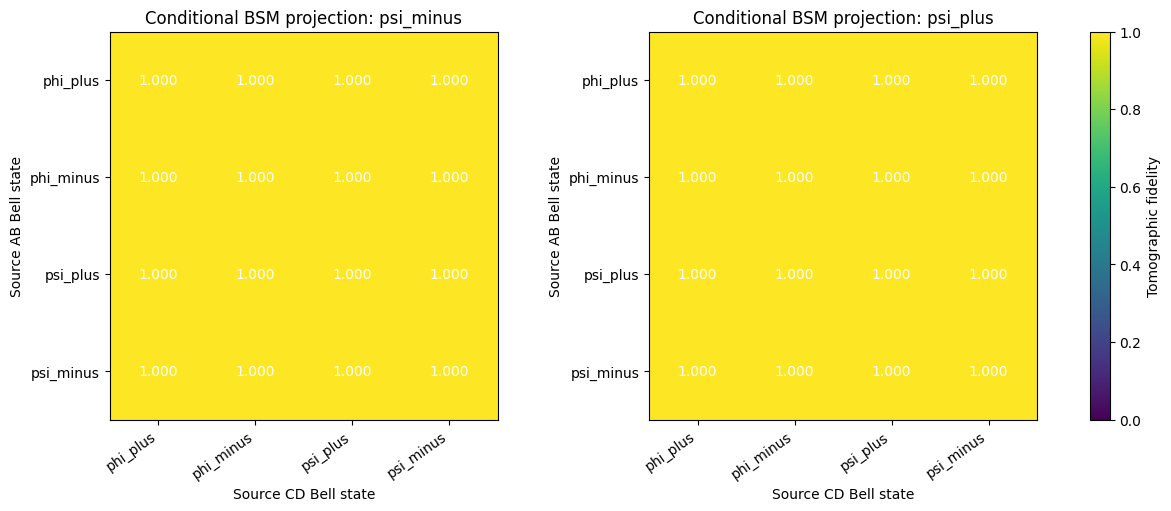

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for ax, bsm_state in zip(axes, ('psi_minus', 'psi_plus')):
    matrix = tomography_results[tomography_results['bsm_bc'] == bsm_state].pivot(
        index='source_ab', columns='source_cd', values='fidelity'
    ).reindex(index=BELL_STATES, columns=BELL_STATES)
    image = ax.imshow(matrix, vmin=0, vmax=1, cmap='viridis')
    ax.set_title(f'Conditional BSM projection: {bsm_state}')
    ax.set_xlabel('Source CD Bell state')
    ax.set_ylabel('Source AB Bell state')
    ax.set_xticks(range(4), BELL_STATES, rotation=35, ha='right')
    ax.set_yticks(range(4), BELL_STATES)
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f'{matrix.iloc[i, j]:.3f}', ha='center', va='center', color='white')
fig.colorbar(image, ax=axes, label='Tomographic fidelity')

## Inspect reconstructed density matrices

Change the three labels below to inspect any of the 32 experimentally selectable cases.

source_ab             psi_minus
source_cd             psi_minus
bsm_bc                psi_minus
expected_outer_ad     psi_minus
fidelity                    1.0
trace_rho                   1.0
minimum_eigenvalue    -0.115131
Name: 30, dtype: object


C:\Users\ana35\OneDrive - NIST\Desktop\cooding\sequence_simulator\SeQUeNCe-ai-dataset\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  func(*args, **kwargs)


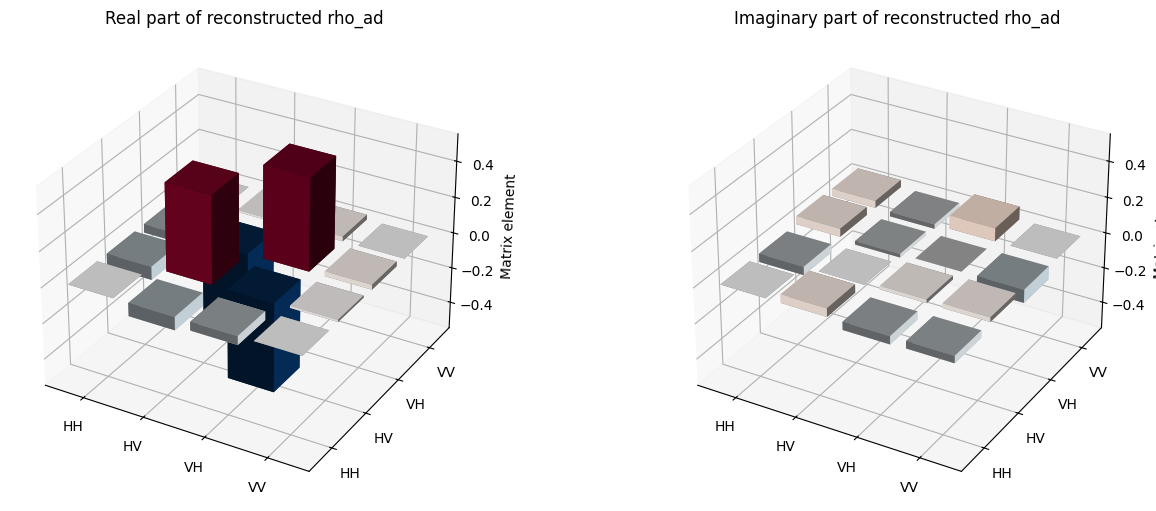

In [8]:
SOURCE_AB = 'psi_minus'
SOURCE_CD = 'psi_minus'
BSM_BC = 'psi_minus'

selected = tomography_results[
    (tomography_results.source_ab == SOURCE_AB)
    & (tomography_results.source_cd == SOURCE_CD)
    & (tomography_results.bsm_bc == BSM_BC)
].iloc[0]
rho = selected.rho_ad

labels = ['HH', 'HV', 'VH', 'VV']
x, y = np.meshgrid(np.arange(4), np.arange(4))
fig = plt.figure(figsize=(13, 5), constrained_layout=True)
for position, (matrix, title) in enumerate(((rho.real, 'Real'), (rho.imag, 'Imaginary')), start=1):
    ax = fig.add_subplot(1, 2, position, projection='3d')
    values = matrix.ravel()
    colors = plt.cm.RdBu_r((values + 0.5).clip(0, 1))
    ax.bar3d(x.ravel(), y.ravel(), np.zeros(16), 0.75, 0.75, values, color=colors, shade=True)
    ax.set_title(f'{title} part of reconstructed rho_ad')
    ax.set_xticks(np.arange(4) + 0.375, labels)
    ax.set_yticks(np.arange(4) + 0.375, labels)
    ax.set_zlim(-0.55, 0.55)
    ax.set_zlabel('Matrix element')
print(selected.drop(labels='rho_ad'))

For two $\Psi^-$ sources, conditioning on $\Psi^-_{bc}$ reconstructs $\Psi^-_{ad}$. The leading minus sign shown in some algebraic tables is a global phase and cannot change the reconstructed density matrix. The $\Phi^\pm_{bc}$ projections remain algebraic predictions only because two photons reaching one threshold detector do not provide a unique operational BSM event.